# Exploratory Data Analysis

### 1. Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Load Final Integrated Dataset

In [2]:
data = pd.read_csv("../data/final_integrated_dataset.csv", parse_dates=['start_date','signup_date','last_churn_date','end_date'])

### 3. Step wise EDA

In [3]:
#1. Basic Info
print("Shape:", data.shape)
print("\nData types:\n", data.dtypes)
print("\nMissing values (top 20):\n", data.isna().sum().sort_values(ascending=False).head(20))

Shape: (5000, 49)

Data types:
 subscription_id                               object
account_id                                    object
start_date                            datetime64[ns]
end_date                                      object
plan_tier_subscription                        object
seats_subscription                             int64
mrr_amount                                     int64
arr_amount                                     int64
is_trial_x                                      bool
upgrade_flag                                    bool
downgrade_flag                                  bool
churn_flag_x                                    bool
billing_frequency                             object
auto_renew_flag                                 bool
is_active                                      int64
subscription_duration_days                     int64
avg_mrr_per_seat                             float64
revenue_ratio                                float64
account_name  

#### Dataset Overview Markdown
- **Shape** : 5000 rows × 49 columns
- **Data types** : Mixed (numeric, boolean, datetime, object)
- **Missing values** : Mostly in churn-related columns (last_churn_date, total_churn_events, top_reason, any_reactivation, any_preceding_upgrade, any_preceding_downgrade)


Churn distribution:
has_churned
True     3528
False    1472
Name: count, dtype: int64


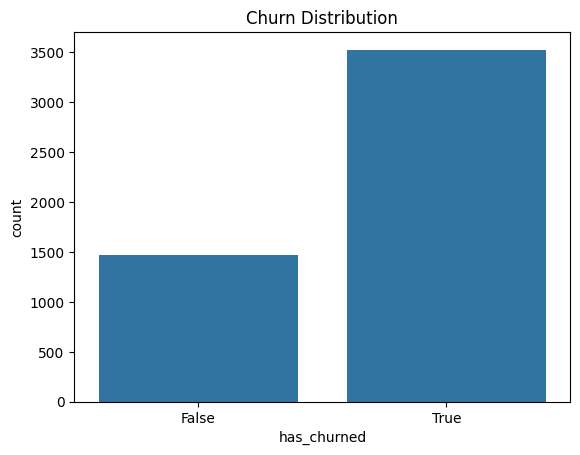

In [11]:
#2. Target / Churn Overview
if 'has_churned' in data.columns:
    print("\nChurn distribution:")
    print(data['has_churned'].value_counts())
    sns.countplot(x='has_churned', data=data)
    plt.title("Churn Distribution")
    plt.show()

#### Target/Churn Overview
- Churn distribution:
  - **True**: 3528 subscriptions
  - **False**: 1472 subscriptions
- The dataset is slightly imbalanced, with more churned subscriptions than non-churned.

In [5]:
#3. Numeric Feature Summary
numeric_cols = data.select_dtypes(include=['int64','float64']).columns.tolist()
print("\nNumeric feature summary:\n", data[numeric_cols].describe())


Numeric feature summary:
        seats_subscription    mrr_amount     arr_amount   is_active  \
count         5000.000000   5000.000000    5000.000000  5000.00000   
mean            29.852000   2267.749400   27212.992800     0.90280   
std             23.089771   3421.375348   41056.504178     0.29626   
min              1.000000      0.000000       0.000000     0.00000   
25%             14.000000    285.000000    3420.000000     1.00000   
50%             24.000000    931.000000   11172.000000     1.00000   
75%             40.000000   2786.000000   33432.000000     1.00000   
max            189.000000  33830.000000  405960.000000     1.00000   

       subscription_duration_days  avg_mrr_per_seat  revenue_ratio  \
count                   5000.0000       5000.000000    5000.000000   
mean                     414.6084         76.739600      10.132800   
std                      184.2057         79.840247       4.350144   
min                        0.0000          0.000000       0.00

#### Numeric Feature Summary
- Key numeric features include:
    - mrr_amount, arr_amount, seats_x, avg_mrr_per_seat
- **Usage metrics**: usage_count_feat, usage_duration_secs_feat, error_count_feat
- **Ticket metrics**: total_tickets, num_escalated_tickets, resolution_time_hours_ticket, first_response_time_minutes_ticket, satisfaction_score_ticket
- **Variances** differ significantly across features; some features (like mrr_amount and arr_amount) have wide ranges.

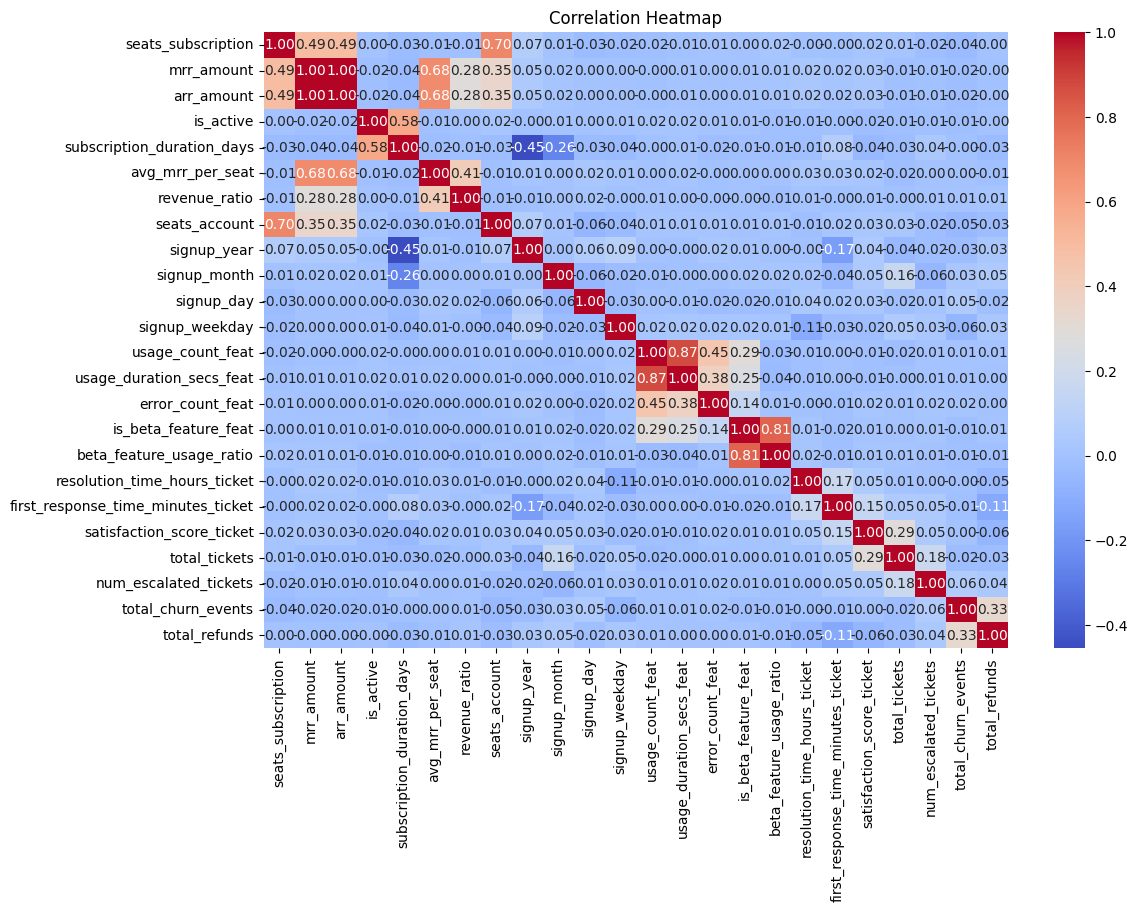

In [6]:
#4. Correlation Heatmap (numeric features)
plt.figure(figsize=(12,8))
sns.heatmap(data[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Heatmap")
plt.show()

#### Correlation Insights
- Positive correlations observed between revenue-related features (mrr_amount & arr_amount)
- Weak correlations between churn (has_churned) and most numeric usage metrics
- Some features like avg_mrr_per_seat and subscription_duration_days have moderate correlation with revenue.

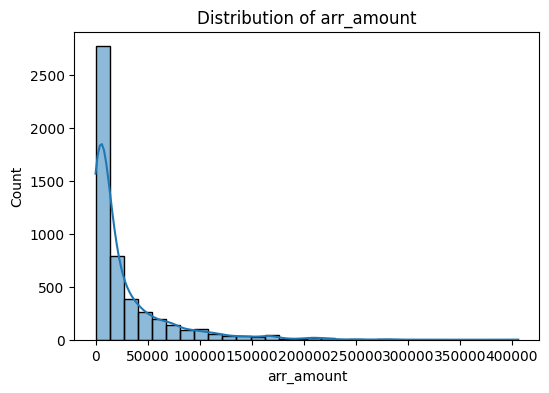

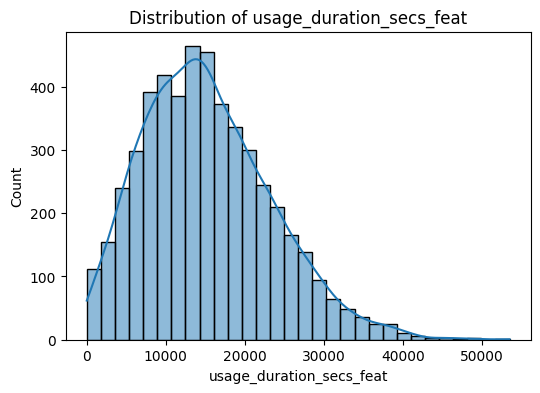

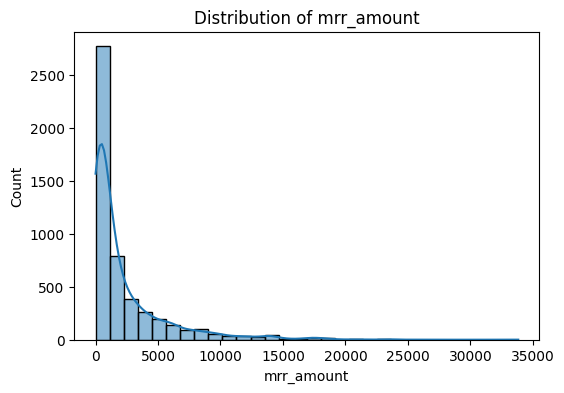

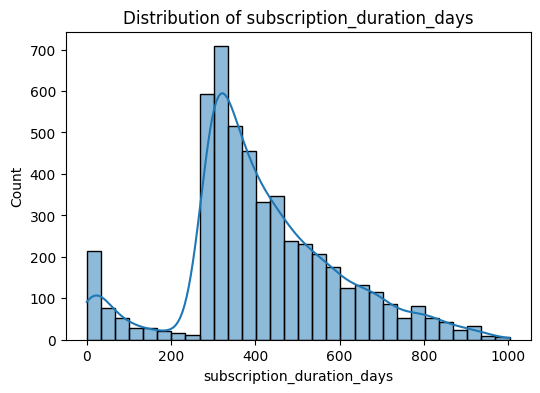

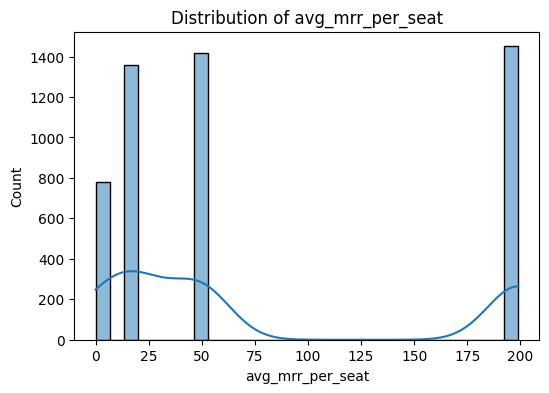

In [7]:
#5. Quick Distribution Plots (top 5 numeric features by variance)
variances = data[numeric_cols].var().sort_values(ascending=False)
top5_numeric = variances.head(5).index.tolist()

for col in top5_numeric:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()



Value counts for subscription_id:
subscription_id
S-71fc3d    1
S-8cec59    1
S-0f6f44    1
S-51c0d1    1
S-f81687    1
S-cff5a2    1
S-4b9b13    1
S-dceac6    1
S-0896bc    1
S-e09e04    1
Name: count, dtype: int64


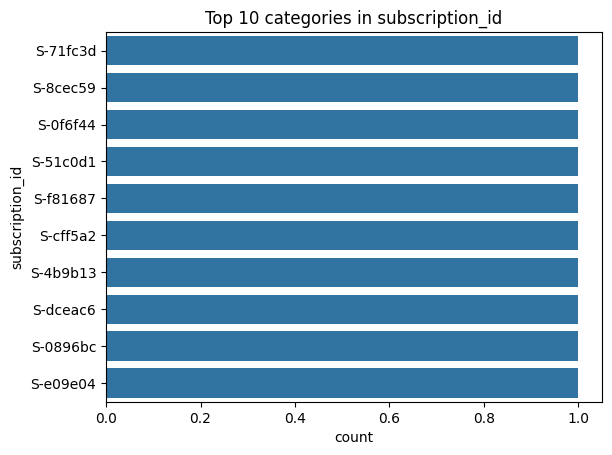


Value counts for account_id:
account_id
A-592832    19
A-726cfa    19
A-5a92e7    19
A-d4ac0e    19
A-8bde0c    18
A-5a215a    18
A-6f8ad2    17
A-82d8a6    17
A-692f18    17
A-781cc0    16
Name: count, dtype: int64


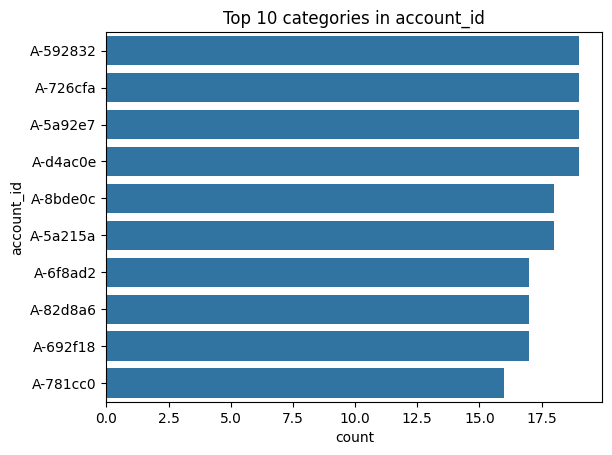


Value counts for end_date:
end_date
0                      4514
2024-12-31 00:00:00      24
2024-12-29 00:00:00      19
2024-12-30 00:00:00      18
2024-12-28 00:00:00      10
2024-12-26 00:00:00       8
2024-12-03 00:00:00       7
2024-12-18 00:00:00       7
2024-12-21 00:00:00       7
2024-12-15 00:00:00       7
Name: count, dtype: int64


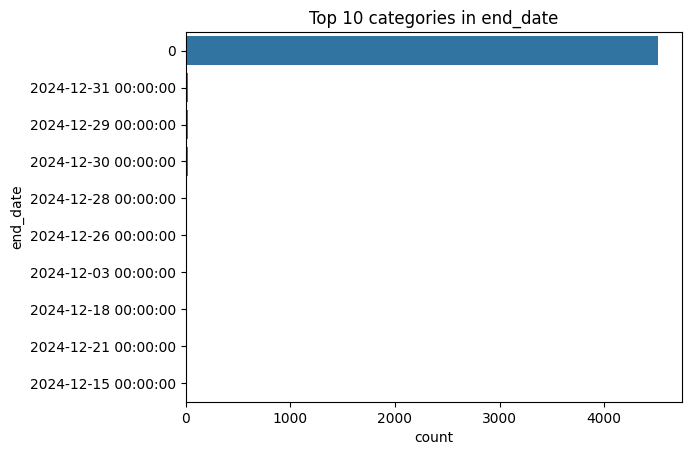


Value counts for plan_tier_subscription:
plan_tier_subscription
Enterprise    1723
Pro           1675
Basic         1602
Name: count, dtype: int64


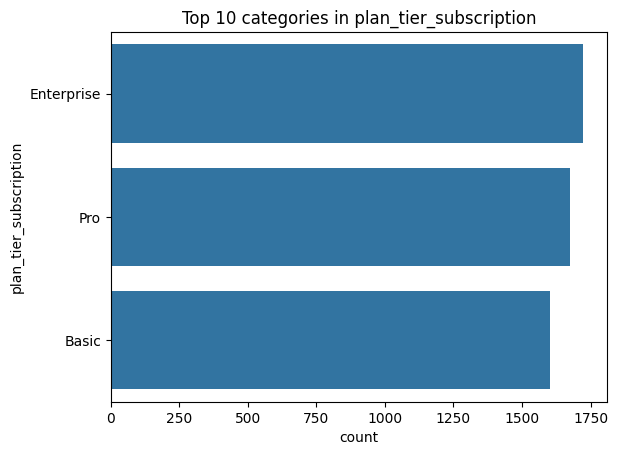


Value counts for billing_frequency:
billing_frequency
monthly    2539
annual     2461
Name: count, dtype: int64


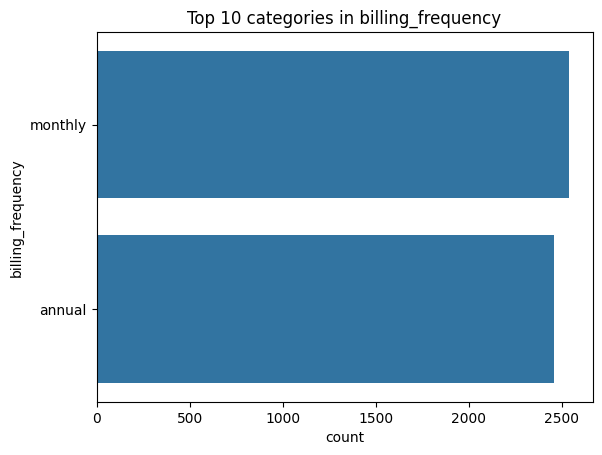

In [8]:
#6. Categorical Feature Overview (top 5)
cat_cols = data.select_dtypes(include='object').columns.tolist()
for col in cat_cols[:5]:
    print(f"\nValue counts for {col}:")
    print(data[col].value_counts().head(10))
    sns.countplot(y=col, data=data, order=data[col].value_counts().index[:10])
    plt.title(f"Top 10 categories in {col}")
    plt.show()

#### Categorical Feature Insights
- Major categorical features: plan_tier_x, plan_tier_y, billing_frequency, industry, country
- Most accounts are in Pro or Enterprise tiers
- Billing frequency and industry distributions are skewed, with a few dominant categories

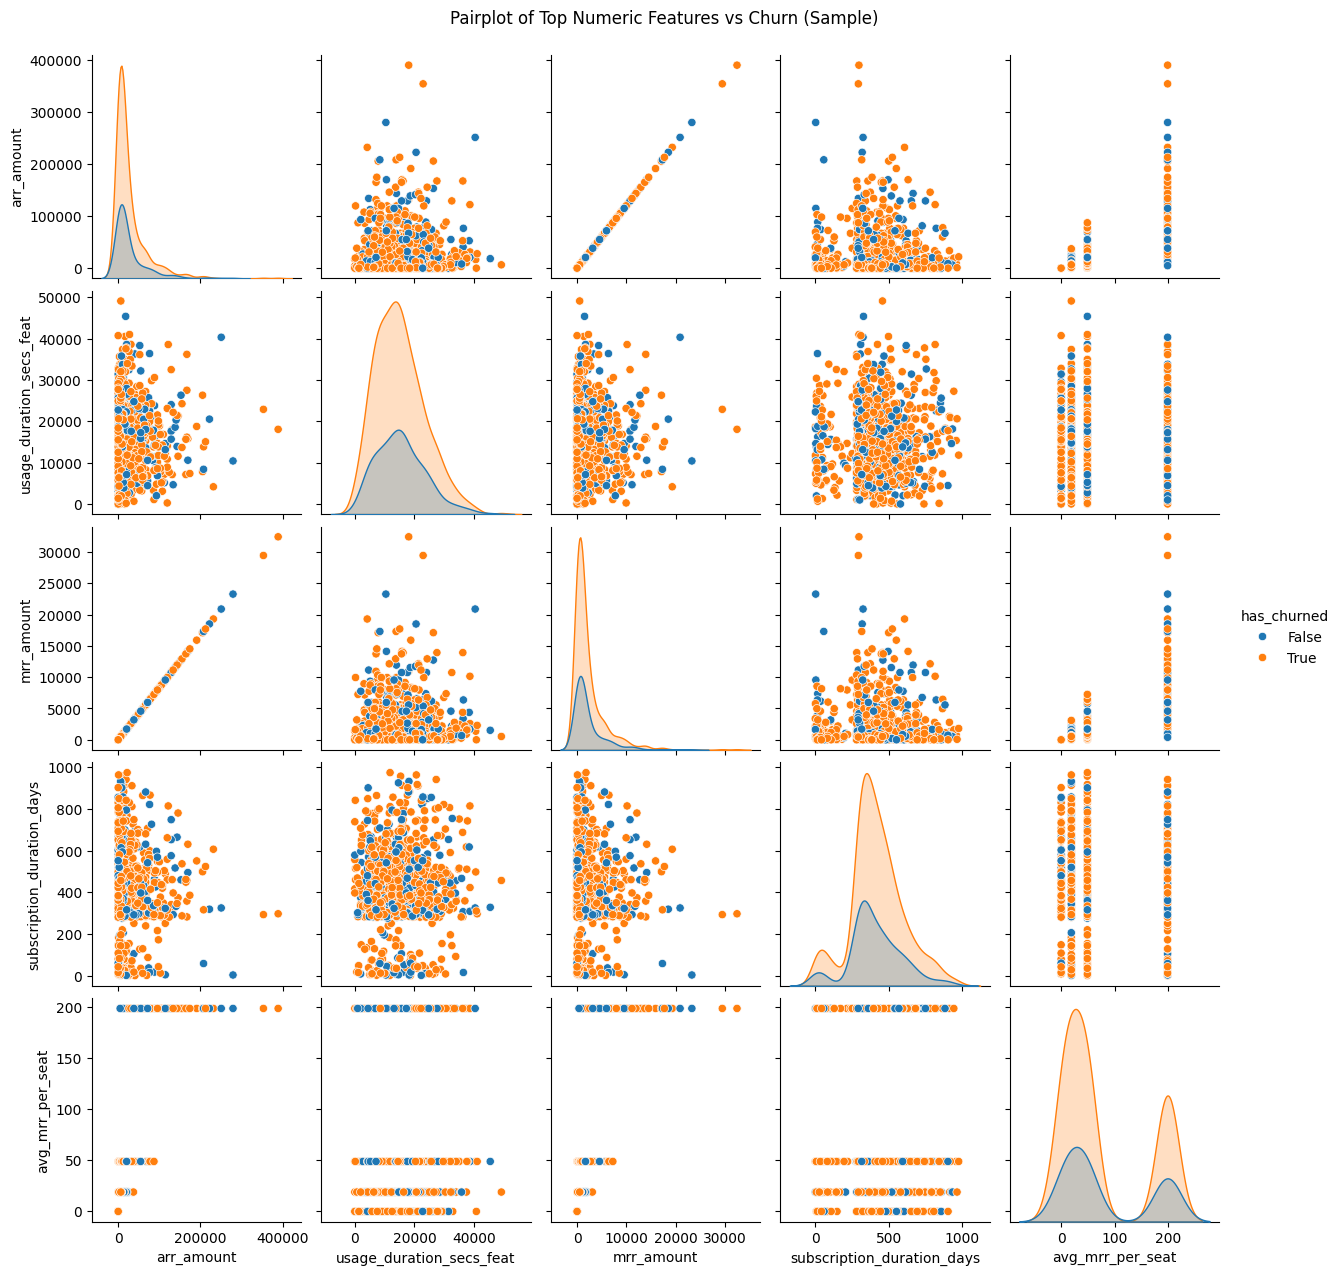

In [9]:
#7. Quick Insight: Pairplot of top numeric features vs churn (optional, small sample for speed)
if 'has_churned' in data.columns:
    sample = data.sample(n=1000, random_state=42)  # subsample to speed up pairplot
    sns.pairplot(sample, vars=top5_numeric, hue='has_churned', diag_kind='kde')
    plt.suptitle("Pairplot of Top Numeric Features vs Churn (Sample)", y=1.02)
    plt.show()


#### Quick Visual Insights
- Churn distribution shows slight imbalance → may require stratification in modeling
- Histograms reveal skewed numeric distributions (e.g., revenue and usage metrics)
- Pairplots of top numeric features vs churn show separability patterns are limited but worth exploring

### END OF EDA
